In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from pathlib import Path
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
from helper import DeepfakeDataset, face_detect_trace, fft_transform
from models import Model1, Model0, Model2

SEED = 38

torch.manual_seed(SEED)

In [2]:
print("Test Dataset")
test_dataset = DeepfakeDataset("preprocessed/test", mode="test")
sample = test_dataset[0]
print(sample["spatial"].shape)
print(sample["frequency"].shape)
print(sample["label"])

Test Dataset
torch.Size([10, 3, 224, 224])
torch.Size([10, 1, 224, 224])
tensor(1.)


In [3]:
test_loader   = DataLoader(test_dataset, batch_size=8, shuffle=False)

model0 = Model0()
model1 = Model1()
model2 = Model2()

model0.load_state_dict(torch.load("Model0.pth"))
model1.load_state_dict(torch.load("Model1.pth"))
model2.load_state_dict(torch.load("Model2.pth"))

<All keys matched successfully>

In [4]:
def test(model, loader = test_loader):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = [] 
    
    pbar = tqdm(loader)

    with torch.no_grad():
        for batch in pbar:
            spatial = batch["spatial"]
            frequency = batch["frequency"]
            labels = batch["label"].unsqueeze(1)

            outputs = model(spatial, frequency)

            probs = torch.sigmoid(outputs)

            all_probs.extend(probs.cpu().numpy())
            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

preds0, labels0, probs0 = test(model0)
preds1, labels1, probs1 = test(model1)
preds2, labels2, probs2 = test(model2)

acc = accuracy_score(labels0, preds0)
prec = precision_score(labels0, preds0)
rec = recall_score(labels0, preds0)
f1 = f1_score(labels0, preds0)

print("\nModel 0 metrics")
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1: {f1}")

acc = accuracy_score(labels1, preds1)
prec = precision_score(labels1, preds1)
rec = recall_score(labels1, preds1)
f1 = f1_score(labels1, preds1)

print("\n\nModel 1 metrics")
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1: {f1}")

acc = accuracy_score(labels2, preds2)
prec = precision_score(labels2, preds2)
rec = recall_score(labels2, preds2)
f1 = f1_score(labels2, preds2)

print("\n\nModel 2 metrics")
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1: {f1}")

100%|██████████| 60/60 [02:07<00:00,  2.12s/it]


Model 0 metrics
Accuracy: 0.8875
Precision: 0.842741935483871
Recall: 0.9330357142857143
F1: 0.885593220338983


Model 1 metrics
Accuracy: 0.88125
Precision: 0.8678414096916299
Recall: 0.8794642857142857
F1: 0.8736141906873615


Model 2 metrics
Accuracy: 0.9020833333333333
Precision: 0.9154929577464789
Recall: 0.8705357142857143
F1: 0.8924485125858124


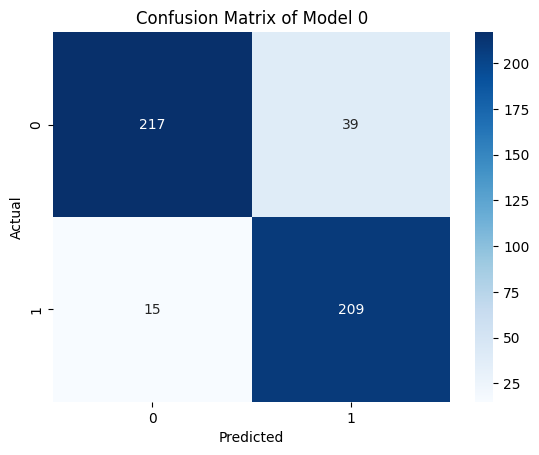

In [5]:
cm = confusion_matrix(labels0, preds0)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Model 0")
plt.show()

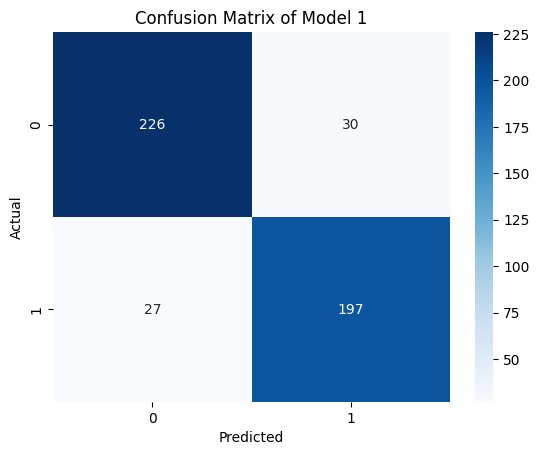

In [6]:
cm = confusion_matrix(labels1, preds1)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Model 1")
plt.show()

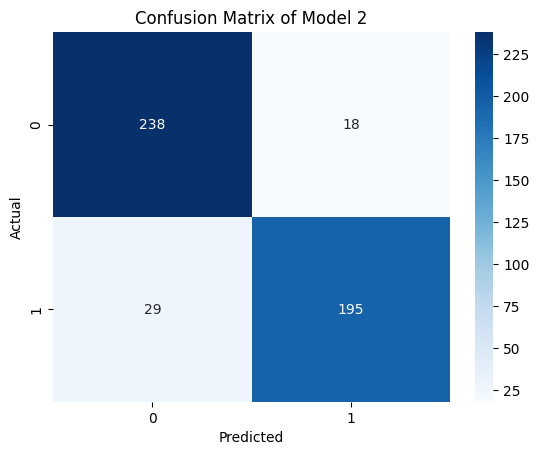

In [7]:
cm = confusion_matrix(labels2, preds2)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Model 2")
plt.show()

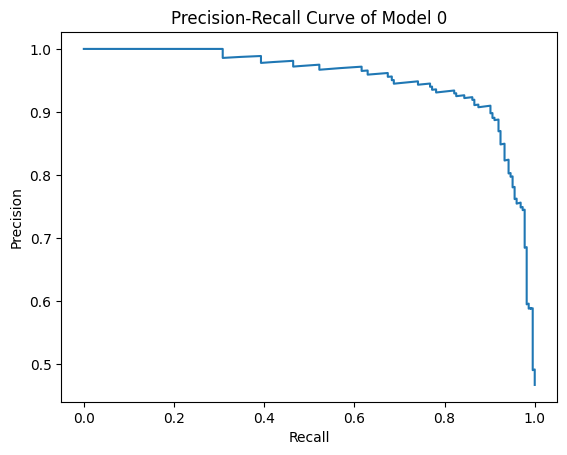

In [9]:
precision0, recall0, threshold0 = precision_recall_curve(labels0, probs0)

precision1, recall1, threshold1 = precision_recall_curve(labels1, probs1)

precision2, recall2, threshold2 = precision_recall_curve(labels2, probs2)

plt.figure()
plt.plot(recall0, precision0)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve of Model 0")
plt.show()

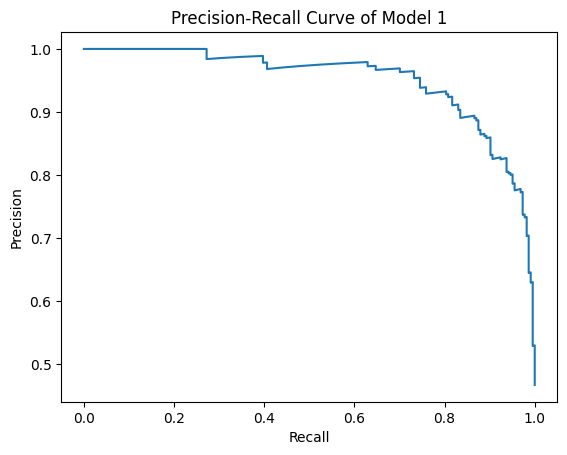

In [10]:
plt.figure()
plt.plot(recall1, precision1)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve of Model 1")
plt.show()

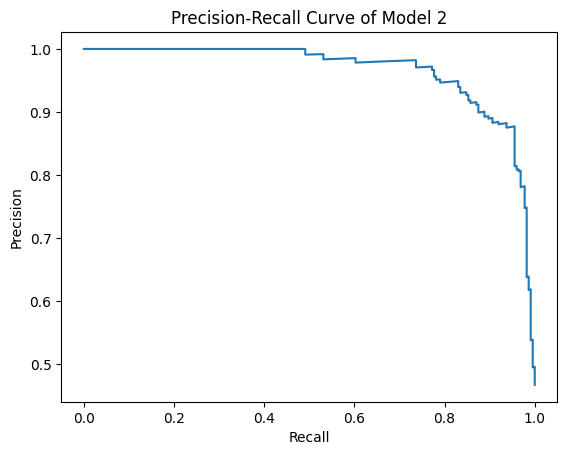

In [16]:
plt.figure()
plt.plot(recall2, precision2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve of Model 2")
plt.show()